In [2]:
import pandas as pd
import numpy as np
import importlib
from tqdm import tqdm

from sklearn.metrics import silhouette_score

import networkx as nx
import community as community_louvain

import plotly.express as px
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import utility_functions as uf

In [28]:
df_cs_yearly = pd.read_csv(uf.PATH+"df_cs_yearly.csv", index_col = [0, 1, 2]).xs("individual", level=2)
df_prob_yearly = df_cs_yearly.div(df_cs_yearly.sum(axis=1), axis=0)

n_years = 5

df_cs_yearly = (
    df_cs_yearly
    .sort_index()
    .groupby(level=0)
    .rolling(n_years).sum()
    .reset_index(level=0, drop=True)
)
df_prob_yearly = df_cs_yearly.div(df_cs_yearly.sum(axis=1), axis=0)

df_dist_yearly = pd.read_csv(uf.PATH+"df_dist_w1_rolling_yearly_individual.csv", index_col=[0, 1])

In [4]:
df_cutoff = (
    pd.DataFrame({}, index=df_cs_yearly.index)
    .assign(
        total = df_cs_yearly.sum(axis=1),
        cutoff_5000 = lambda df: (df.total >= 5000).astype(int),
        cutoff_1000 = lambda df: (df.total >= 1000).astype(int),
    )
)

In [5]:
year = 2013

cutoff = 500
param = "total"

country_idx = df_cutoff.xs(year, level=1).query(param+f" >= @cutoff").index.to_list()
df_cs = df_cs_yearly.xs(year, level=1).loc[country_idx]


df_prob = df_cs.div(df_cs.sum(axis=1), axis=0)

subfield_tree = uf.get_subfield_tree(uf.df_topics)

df_dist = df_dist_yearly.xs(year, level=1).loc[country_idx, country_idx]

np.fill_diagonal(df_dist.values, np.nan)

In [6]:
df_cs_example = df_cs
df_example = df_dist

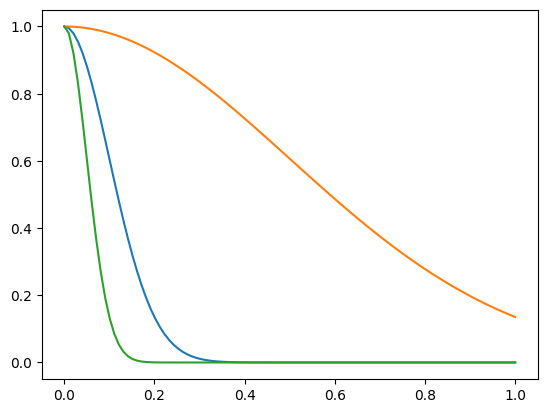

In [7]:
x = np.linspace(0, 1, 100)
y1 = np.exp(-x**2 / (2 * 0.1**2))
y2 = np.exp(-x**2 / (2 * 0.5**2))
y3 = np.exp(-x**2 / (2 * 0.05**2))

plt.plot(x, y1)
plt.plot(x, y2)
plt.plot(x, y3)

In [8]:
res = plt.hist(D.flatten(), bins=50)

NameError: name 'D' is not defined

In [ ]:
D = df_example.fillna(0).values

# similarity = 1 / (1 + D)
sigma = 0.15
similarity = np.exp(-D**2 / (2 * sigma**2))

G = nx.from_numpy_array(similarity)

np.random.seed(0)

partition = community_louvain.best_partition(G, weight="weight", resolution=1)
labels = np.array(list(partition.values()))
df_map = (
    pd.DataFrame(labels, index=df_example.index, columns=["cluster"])
    .merge(uf.df_country[["alpha-2", "alpha-3"]], left_index=True, right_on="alpha-2")
    .merge(df_cs_example.sum(axis=1).to_frame("total_articles"), left_on="alpha-2", right_index=True)
)

print("Clusters: ")
print(pd.Series(labels).value_counts())
print()

print("Silhouette Score: ", silhouette_score(D, list(labels), metric="precomputed"))
print("Dunn Index: ", uf.dunn_index(df_example, labels))
print("Modularity: ", community_louvain.modularity(partition, G, weight="weight"))

Clusters: 
1    42
2    36
3    31
0     1
Name: count, dtype: int64

Silhouette Score:  0.28760746560289985
Dunn Index:  0.08450991897912331
Modularity:  0.20269879565221477


In [9]:
_ = plt.hist(similarity.flatten())

NameError: name 'similarity' is not defined

In [10]:
year = 2017
clusters_tmp = list(df_map.cluster.sort_values().drop_duplicates().astype(int))

max_n_clusters = int(df_map.cluster.max())

fig = px.choropleth(
    df_map.sort_values("cluster").assign(cluster_str=lambda df: df.cluster.astype(str)),
    locations="alpha-3",
    color="cluster_str",
    locationmode="ISO-3",
    color_continuous_scale="Plasma",
    title="Clusters: "+str(year)
)
fig.update_layout(
    margin=dict(l=0, r=0, t=30, b=0)
)
fig.show()

NameError: name 'df_map' is not defined

In [11]:
# get raw mapping

start_year = 1970
end_year = 2023

subfield_tree = uf.get_subfield_tree(uf.df_topics)

df_map_yearly_list = []
medoid_list = []

cutoff = 500

# switch_years = {1998: 3}

silhouette_list = []
medoid_silhouette_list = []

for year_loop in range(start_year, end_year+1):
    country_idx = df_cutoff.xs(year_loop, level=1).query(f"total >= @cutoff").index.to_list()
    # df_cs = df_cs_yearly.xs(year, level=1).loc[country_idx]
    # country_idx = df_cs_roll_yearly.xs(year_loop, level=1).sum(axis=1).to_frame("total").query("total >= @cap_articles").index.to_list()
    
    df_dist_loop = (
        df_dist_yearly
        .xs(year_loop, level=1)
        .loc[country_idx, country_idx]
    )
    df_dist_loop = df_dist_loop.loc[df_dist_loop.index, df_dist_loop.index]
    D_loop = df_dist_loop.loc[df_dist_loop.index, df_dist_loop.index].fillna(0).values
    
    if df_dist_loop.empty:
        continue
    # similarity = 1 / (1 + D_loop)
    sigma = 0.1
    similarity = np.exp(-D_loop**2 / (2 * sigma**2))

    G = nx.from_numpy_array(similarity)

    np.random.seed(0)

    partition = community_louvain.best_partition(G, weight="weight")
    labels = np.array(list(partition.values()))

    silhouette_list.append(silhouette_score(D_loop, labels, metric="precomputed"))

    df_map_yearly_list.append((
        pd.DataFrame(labels, index=df_dist_loop.index, columns=["cluster"])
        .assign(year=year_loop)
        .reset_index(names="country")
    ))

df_map_yearly = pd.concat(df_map_yearly_list)

# df_map_yearly.to_csv(uf.PATH+f"df_map_{param_value}_linkage_yearly_short_w1_{mode}.csv", index=False)

In [12]:
df_map_yearly_full = (
    df_map_yearly
    .merge(df_cs_yearly.sum(axis=1).to_frame("total_articles"), left_on=["country", "year"], right_index=True)
)

In [13]:
import numpy as np

# --------- TREE UTILS ---------

def get_children(node):
    return node.get("branches", [])

def is_leaf(node):
    return "branches" not in node or len(node["branches"]) == 0


# --------- STEP 1: subtree masses ---------

def compute_subtree_masses(node, p):
    """
    node: tree node
    p: dict {leaf_id: prob}
    returns: dict {node_id: subtree_mass}
    """
    subtree = {}

    def dfs(n):
        if is_leaf(n):
            mass = p.get(str(n["id"]), 0.0)
        else:
            mass = sum(dfs(child) for child in get_children(n))
        subtree[str(n["id"])] = mass
        return mass

    dfs(node)
    return subtree


# --------- STEP 2: aggregate (median / mean) ---------

def aggregate_subtree_masses(subtree_list, use_median=True):
    """
    subtree_list: list of dicts {node_id: subtree_mass}
    """
    node_ids = subtree_list[0].keys()
    m = {}

    for node_id in node_ids:
        values = [subtree[node_id] for subtree in subtree_list]
        if use_median:
            m[node_id] = np.median(values)
        else:
            m[node_id] = np.mean(values)

    return m


# --------- STEP 3: reconstruct leaf probabilities ---------

def reconstruct_leaf_distribution(node, m):
    """
    m: dict {node_id: aggregated subtree mass}
    returns: dict {leaf_id: prob}
    """
    p_bar = {}

    def dfs(n):
        children = get_children(n)

        if not children:  # leaf
            p_bar[str(n["id"])] = m[str(n["id"])]
            return m[str(n["id"])]

        children_mass = sum(dfs(child) for child in children)
        return m[str(n["id"])]

    dfs(node)
    return p_bar


# --------- MAIN FUNCTION ---------

def wasserstein_tree_barycenter(tree, distributions, use_median=True):
    """
    tree: your nested dict
    distributions: list of dicts {leaf_id: prob}
    """

    # Step 1: subtree masses for each distribution
    subtree_list = [
        compute_subtree_masses(tree, p)
        for p in distributions
    ]

    # Step 2: aggregate
    m = aggregate_subtree_masses(subtree_list, use_median=use_median)

    # Step 3: reconstruct
    p_bar = reconstruct_leaf_distribution(tree, m)

    return p_bar

In [29]:
df_sf = uf.df_topics[["subfield_id", "field_id", "domain_id"]].drop_duplicates().sort_values(["domain_id", "field_id", "subfield_id"])
df_prob_yearly = df_prob_yearly.T.loc[df_sf.subfield_id.astype(str)].T

In [83]:
def find_dynamic_communities_profiles(df_map_yearly: pd.DataFrame, df_prob_yearly: pd.DataFrame, use_median=True):
    df_map_list = df_map_yearly.groupby(["year", "cluster"], as_index=False).country.agg(list)
    years_list = df_map_list.year.drop_duplicates().sort_values().to_list()
    subfield_tree = uf.get_subfield_tree(uf.df_topics)

    threshold = 0.15
    share_articles = 0.01

    initial_communities = df_map_list.query(f"year == {years_list[0]}").country.to_list()

    dyn_communities = {}
    for i in range(1, len(initial_communities)+1):
        ic = initial_communities[i-1]
        dyn_communities[i] = uf.get_w1_barycenter(df_prob_yearly.xs(years_list[0], level=1).loc[ic].fillna(0)).T.to_dict()[0]

    dyn_communities[1]

    dyn_community_idx = len(initial_communities) + 1
    # print(dyn_communities.keys(), dyn_community_idx)
    match_list = []

    for year_loop in years_list[1:]:
        year_communities = df_map_list.query("year == @year_loop").country.to_list()
        year_comm_number = df_map_list.query("year == @year_loop").cluster.to_list()
        for i, comm in enumerate(year_communities):
            comm_articles = df_map_yearly.query(f"year == @year_loop and country in @comm").total_articles.sum() / df_map_yearly.query(f"year == @year_loop").total_articles.sum()

            if comm_articles <= share_articles:
                match_list.append({"year": year_loop, "cluster": year_comm_number[i], "dyn_comm": 0, "n_countries": len(comm), "n_articles": comm_articles, "dyn_comm_str": str(0)})
                continue

            df_prob = df_prob_yearly.xs(year_loop, level=1).loc[comm].fillna(0)
            # print(df_prob)
            comm_profile = uf.get_w1_barycenter(df_prob)
            # print("comm profile: ", comm_profile)
            dyn_match = -1
            dyn_sim = 1
            for dyn_idx, dyn in dyn_communities.items():
                # print("dyn: ", dyn)
                # print("comm: ", comm_profile.T.to_dict()[0])
                _, _, dist = uf.get_dist_w1_tree(subfield_tree, comm_profile.T.to_dict()[0], dyn)
                # print(dist)
                if (dist <= threshold) and (dist <= dyn_sim):
                    dyn_match = dyn_idx
                    dyn_sim = dist
            if dyn_match == -1:
                dyn_communities[dyn_community_idx] = comm_profile.T.to_dict()[0]
                match_list.append({"year": year_loop, "cluster": year_comm_number[i], "dyn_comm": dyn_community_idx, "n_countries": len(comm), "n_articles": comm_articles, "dyn_comm_str": str(dyn_community_idx)})
                dyn_community_idx += 1
            else:
                dyn_communities[dyn_match] = comm_profile.T.to_dict()[0]
                match_list.append({"year": year_loop, "cluster": year_comm_number[i], "dyn_comm": dyn_match, "n_countries": len(comm), "n_articles": comm_articles, "dyn_comm_str": str(dyn_match)})
    return match_list

In [84]:
importlib.reload(uf)

<module 'utility_functions' from '/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py'>

In [85]:
df_dyn_mapping = pd.json_normalize(find_dynamic_communities_profiles(df_map_yearly_full, df_prob_yearly, use_median=False))

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1241: RuntimeWarning: divide by zero encountered in matmul
  q12 = np.matmul(q11, adj_leaves)
/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1241: RuntimeWarning: overflow encountered in matmul
  q12 = np.matmul(q11, adj_leaves)
/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1241: RuntimeWarning: invalid value encountered in matmul
  q12 = np.matmul(q11, adj_leaves)
/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1284: RuntimeWarning: divide by zero encountered in matmul
  wass_list = wass_array_short @ mu_list.T
/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1284: RuntimeWarning: overflow encountered in matmul
  wass_list = wass_array_short @ mu_list.T
/Users/irinavorobeva/Documents/Sociology/Geography T

In [726]:
# def jaccard_similarity(a, b):
#     a, b = set(a), set(b)
#     return len(a & b) / len(a | b)

# def find_dynamic_communities(df_map_yearly: pd.DataFrame):
#     df_map_list = df_map_yearly.groupby(["year", "cluster"], as_index=False).country.agg(list)
#     years_list = df_map_list.year.drop_duplicates().sort_values().to_list()

#     threshold = 0.5
#     share_articles = 0.01

#     initial_communities = df_map_list.query(f"year == {years_list[0]}").country.to_list()
#     dyn_communities = dict(zip(range(1, len(initial_communities)+1), initial_communities))

#     dyn_community_idx = len(initial_communities) + 1
#     print(dyn_communities.keys(), dyn_community_idx)
#     match_list = []

#     for year_loop in years_list[1:]:
#         year_communities = df_map_list.query("year == @year_loop").country.to_list()
#         year_comm_number = df_map_list.query("year == @year_loop").cluster.to_list()
#         for i, comm in enumerate(year_communities):
#             comm_articles = df_map_yearly.query(f"year == @year_loop and country in @comm").total_articles.sum() / df_map_yearly.query(f"year == @year_loop").total_articles.sum()

#             if comm_articles <= share_articles:
#                 match_list.append({"year": year_loop, "cluster": year_comm_number[i], "dyn_comm": 0, "n_countries": len(comm), "n_articles": comm_articles, "dyn_comm_str": str(0)})
#                 continue

#             dyn_match = -1
#             dyn_sim = 0
#             for dyn_idx, dyn in dyn_communities.items():
#                 sim = jaccard_similarity(comm, dyn)
#                 if (sim >= threshold) and (sim >= dyn_sim):
#                     dyn_match = dyn_idx
#                     dyn_sim = sim
#             if dyn_match == -1:
#                 dyn_communities[dyn_community_idx] = comm
#                 match_list.append({"year": year_loop, "cluster": year_comm_number[i], "dyn_comm": dyn_community_idx, "n_countries": len(comm), "n_articles": comm_articles, "dyn_comm_str": str(dyn_community_idx)})
#                 dyn_community_idx += 1
#             else:
#                 dyn_communities[dyn_match] = comm
#                 match_list.append({"year": year_loop, "cluster": year_comm_number[i], "dyn_comm": dyn_match, "n_countries": len(comm), "n_articles": comm_articles, "dyn_comm_str": str(dyn_match)})
#     return match_list

In [727]:
# df_dyn_mapping = pd.json_normalize(find_dynamic_communities(df_map_yearly_full))

# # noise_dyn_comm = df_dyn_mapping.groupby("dyn_comm").year.count().to_frame("n_years").query("n_years == 1").index.to_list()
# # df_dyn_mapping.loc[df_dyn_mapping["dyn_comm"].isin(noise_dyn_comm), "dyn_comm"] = 0
# # df_dyn_mapping.loc[df_dyn_mapping["dyn_comm"].isin(noise_dyn_comm), "dyn_comm_str"] = "0"

In [86]:
df_dyn_mapping_yearly = (
    df_map_yearly_full
    .merge(df_dyn_mapping, left_on=["year", "cluster"], right_on=["year", "cluster"], how="left")
    .drop(columns="cluster")
    .rename(columns={"dyn_comm": "cluster"})
)

In [ ]:
df_map_analysis = df_dyn_mapping_yearly[["year", "country", "cluster"]]
# df_map_analysis.to_csv(uf.PATH+"df_map_analysis.csv", index=False)

In [129]:
df_map_analysis.dropna(subset="cluster")

,year,country,cluster
37,1975,AR,8.0
38,1975,AT,0.0
39,1975,AU,7.0
40,1975,BE,5.0
41,1975,BG,4.0
...,...,...,...
3890,2023,VN,17.0
3891,2023,YE,5.0
3892,2023,ZA,17.0
3893,2023,ZM,18.0


In [109]:
df_stats_cluster = uf.get_cluster_stats(df_map_analysis, df_cs_yearly.reset_index(), df_dist_yearly.reset_index())

In [110]:
df_cluster_prob_yearly_list = []

for year_loop in range(start_year, end_year+1):
    df_cs_loop = df_cs_yearly.xs(year, level=1)
    df_cluster_prob = uf.get_cluster_probabilities(df_map_analysis.query("year==@year_loop"), df_cs_loop)
    df_cluster_prob_yearly_list.append(df_cluster_prob.assign(year=year_loop).reset_index(names="cluster"))
df_cluster_prob_yearly = pd.concat(df_cluster_prob_yearly_list)
# df_cluster_prob_yearly.to_csv(uf.PATH+f"df_prob_{param_value}_medoid_short_yearly_w1_{mode}.csv", index=False)

In [111]:
pivot = df_map_analysis.pivot(index="country", columns="year", values="cluster")
pivot

clusters = pivot.values

# Broadcasting comparison
same_cluster = clusters[:, None, :] == clusters[None, :, :]

# Count matches across years
co_membership = same_cluster.sum(axis=2)

# Convert back to dataframe
df_dist_clusters_yearly = 1 - pd.DataFrame(
    co_membership,
    index=pivot.index,
    columns=pivot.index
) / (end_year - start_year)

df_n_years = pd.DataFrame(
    co_membership,
    index=pivot.index,
    columns=pivot.index
)
df_dist_clusters_yearly = 1 - df_n_years.div(np.diagonal(df_n_years.values))

# df_dist_clusters_yearly.to_csv(uf.PATH+f"df_dist_countries_{param_value}_medoid_short_w1_{mode}.csv", index=True)

In [112]:
import plotly.express as px

fig = px.area(
    df_stats_cluster.replace({0: np.nan}),
    x="year",
    y="countries_share",
    color="cluster",
    title="Cluster share over time (countries)"
)

fig.update_layout(
    yaxis_range=[0, 1],
    xaxis_title="Year",
    yaxis_title="Share"
)

fig.show()

In [113]:
import plotly.express as px

fig = px.area(
    df_stats_cluster,
    x="year",
    y="total_articles_share",
    color="cluster",
    title="Cluster share over time (articles)"
)

fig.update_layout(
    yaxis_range=[0, 1],
    xaxis_title="Year",
    yaxis_title="Share"
)

fig.show()

In [114]:
year = 2023
clusters_tmp = list(df_map_analysis.query("year == @year").dropna().cluster.sort_values().drop_duplicates().astype(int))

max_n_clusters = int(df_map_analysis.cluster.max())

fig = px.choropleth(
    df_map_analysis.sort_values("cluster").query("year==@year").merge(uf.df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2").assign(cluster_str=lambda df: df.cluster.astype(str)),
    locations="alpha-3",
    color="cluster_str",
    locationmode="ISO-3",
    color_continuous_scale="Plasma",
    title="Clusters: "+str(year)
)
fig.update_layout(
    margin=dict(l=0, r=0, t=30, b=0)
)
fig.show()
# _, _ = uf.plot_map_discrete(
#     df_map_analysis.sort_values("cluster").query("year==@year").merge(uf.df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2"),
#     "cluster",
#     title=f"Map of countries by cluster, {year}",
#     max_values=max_n_clusters, 
#     # labels=labels
# )

In [130]:
# year_sort = 2018
y_label = df_dyn_mapping_yearly.query("year == @year").sort_values(["cluster", "total_articles"], ascending=False).country.to_list()

df_plot = (
    df_map_analysis
    # .query("cluster == @cluster")
    .assign(cluster_str=lambda df: df.cluster.astype(str))
    .pivot(index="country", columns="year", values="cluster_str")

    # .replace({cluster: 1})
    # .fillna(0)
)
uf.plotly_heatmap(df_plot.loc[y_label], x_labels=df_plot.columns, y_labels=y_label, line_height=5, y_type="country")

In [116]:
subfield_list = df_cs_yearly.columns.to_list()
df_cluster_prob_yearly = (
    df_cs_yearly
    .fillna(0)
    .merge(df_map_analysis.set_index(["country", "year"]), left_index=True, right_index=True, how="right")
    .reset_index()
    .drop("country", axis=1)
    .groupby(["cluster", "year"])
    [subfield_list]
    .sum()
)
df_cluster_prob_yearly = df_cluster_prob_yearly.div(df_cluster_prob_yearly.sum(axis=1), axis=0)

In [117]:
barycenter_list = []
cluster_by_year = df_map_analysis.query("year == @year").cluster.drop_duplicates().to_list()
for cluster in cluster_by_year:
    cluster_list = df_map_analysis.query("year == @year and cluster == @cluster").country.to_list()
    cluster_profile_list = [df_prob_yearly.xs(year, level=1).loc[c].fillna(0).to_dict() for c in cluster_list]

    subfield_tree = uf.get_subfield_tree(uf.df_topics)

    barycenter_list.append(pd.json_normalize([wasserstein_tree_barycenter(subfield_tree, cluster_profile_list, use_median=True)]).T.rename(columns={0: cluster}))
df_baricenters = pd.concat(barycenter_list, axis=1)

In [118]:
global_country_list = df_map_analysis.query("year == @year").country.to_list()
global_profile_list = [df_prob_yearly.xs(year, level=1).loc[c].fillna(0).to_dict() for c in global_country_list]
df_baricenter_global = pd.json_normalize([wasserstein_tree_barycenter(subfield_tree, global_profile_list, use_median=True)]).T.rename(columns={0: "global_prob"})

In [119]:
uf.get_w1_distances(subfield_tree, df_baricenters.T)

,17.0,18.0,5.0,0.0
17.0,0.000000,0.165260,0.148474,0.614506
18.0,0.165260,0.000000,0.266268,0.737058
5.0,0.148474,0.266268,0.000000,0.661254
0.0,0.614506,0.737058,0.661254,0.000000


In [120]:
df = df_baricenters.sub(df_baricenter_global.global_prob, axis=0).div(df_prob_yearly.xs(year, level=1).std(), axis=0)

px.bar(df, x=df.index, y=df.columns.astype(int), barmode="overlay", title=year)

In [131]:
# df_baricenter_yearly_list = []

# year_list = df_map_analysis.year.drop_duplicates().sort_values().to_list()

# for year_loop in year_list:
#     cluster_list = df_map_analysis.query("year == @year_loop").country.to_list()
#     cluster_profile_list = [df_prob_yearly.xs(year_loop, level=1).loc[c].fillna(0).to_dict() for c in cluster_list]

#     subfield_tree = uf.get_subfield_tree(uf.df_topics)

#     df_baricenter_yearly_list.append(pd.json_normalize([wasserstein_tree_barycenter(subfield_tree, cluster_profile_list, use_median=True)]).T.rename(columns={0: year_loop}))
    
# df_baricenter_global_yearly = pd.concat(df_baricenter_yearly_list, axis=1).T
df_baricenter_global_yearly = pd.read_csv(uf.PATH+"df_barycenter_global_yearly.csv", index_col=0)

In [122]:
# df_baricenter_global_yearly

In [123]:
df_std_yearly = (
    df_prob_yearly
    .groupby(level=1)
    .std()
)

In [124]:
df = df_baricenter_global_yearly
uf.plotly_heatmap(
    df, x_labels=df.columns, y_labels=df.index,
    title=f"Baricenter Probability distribution of subfields globally over time",
    z_min=0, z_max=0.02, line_height=10,
    x_type="subfield", colorscale="non"
)

In [125]:
importlib.reload(uf)

<module 'utility_functions' from '/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py'>

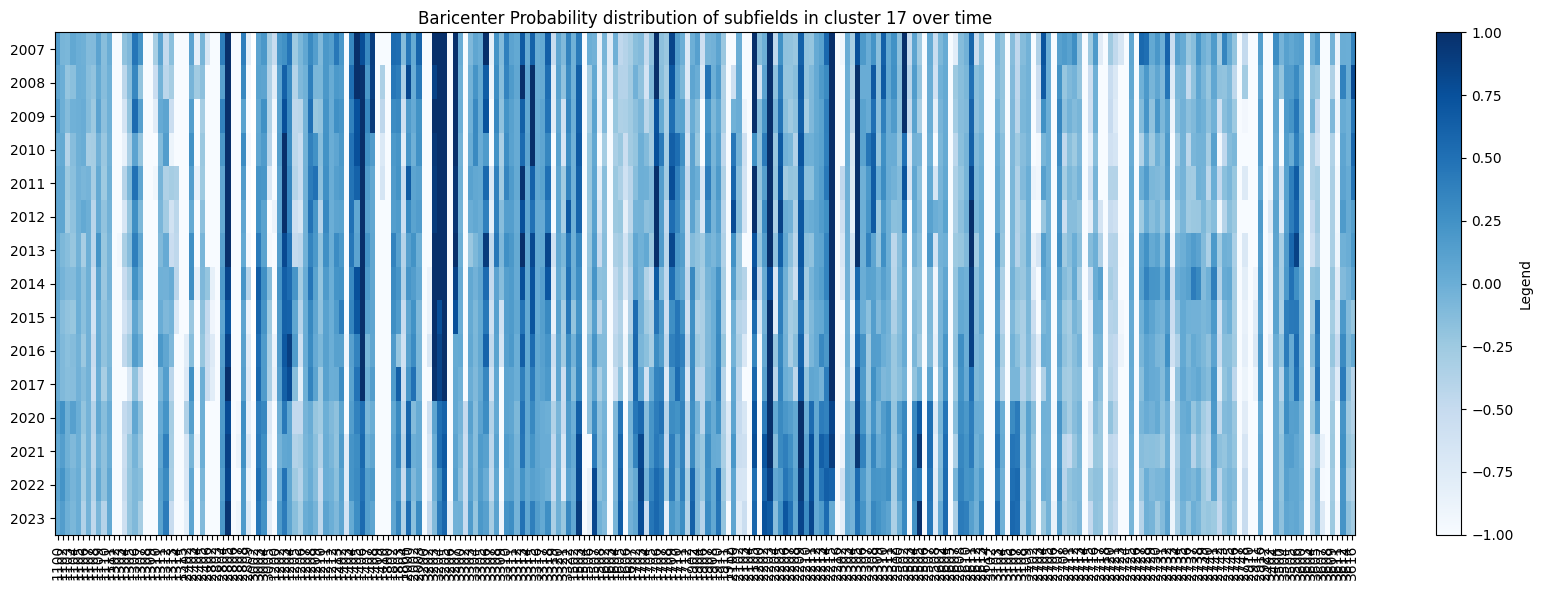

In [135]:
cluster = 17

cluster_years = df_map_analysis.query("cluster == @cluster").year.sort_values().drop_duplicates().to_list()
baricenter_cluster_list = []
for year_loop in cluster_years:
    cluster_list = df_map_analysis.query("year == @year_loop and cluster == @cluster").country.to_list()
    cluster_profile_list = [df_prob_yearly.xs(year, level=1).loc[c].fillna(0).to_dict() for c in cluster_list]
    subfield_tree = uf.get_subfield_tree(uf.df_topics)

    baricenter_cluster_list.append(pd.json_normalize([wasserstein_tree_barycenter(subfield_tree, cluster_profile_list, use_median=False)]).T.rename(columns={0: year_loop}))
df_baricenter_cluster_yearly = pd.concat(baricenter_cluster_list, axis=1).T

df = df_baricenter_cluster_yearly.sub(df_baricenter_global_yearly.loc[df_baricenter_cluster_yearly.index]).div(df_std_yearly.loc[df_baricenter_cluster_yearly.index])

uf.plot_heatmap(
    df, x_labels=df.columns, y_labels=df.index,
    title=f"Baricenter Probability distribution of subfields in cluster {cluster} over time",
    z_min=-1, z_max=1, line_height=10,
    # x_type="subfield", colorscale="non"
)

In [127]:
y_labels = (
    df_map_yearly_full
    # .query("year == @year")
    # .merge(df_cs_yearly.xs(year, level=1).sum(axis=1).to_frame(name="total_articles").reset_index(), left_on="alpha-2", right_index="country", how="left")
    .sort_values(["cluster", "total_articles"], ascending=[True, False])
    ["country"]
    .to_list()
)

uf.plotly_heatmap(df_dist_clusters_yearly.loc[y_label, y_label], x_labels=y_label, y_labels=y_label, line_height=10, colorscale="non", title=year)